## **Latin Hypercube Sampling**

Latin Hypercube Sampling  (LHS) is used to generate stratified random samples of a random vector $\vec{X}$. When estimating the expectation of a function $h(\vec{X})$ using the sample mean, the estimator remains unbiased, but its variance is lower than if the same number of samples were drawn independently from the distribution of $\vec{X}$. LHS doesn’t change the distribution of $\vec{X}$. The samples of $\vec{X}$ are still given from its true distribution $F$. What LHS changes is how the random draws are arranged: stratified instead of purely independent.


### **1. Packages**

In [51]:
import numpy as np
import matplotlib.pyplot as plt

from typing import Callable, Optional, List

### **2. Functions**

Unidimensional

In [151]:
def lhs_1(
        n: int,
        func: Optional[Callable[[np.ndarray | float], np.ndarray | float]] = None,
        tol: float = 1e-6,
    ) -> np.ndarray:
    """
    Latin Hypercube Sampling for unidimensional variables.

    Parameters:
    ----------
    - n: int
    > Number of points.
    - func: Callable[[np.ndarray | float], np.ndarray | float]
    > Quantile function (inverse of cumulative distribution function). If func is None, func(x) = x.
    - tol: float
    > Zero approximation.
    """
    
    #-- Define a random generator
    rng = np.random.default_rng()

    #-- Compute a normalize distribution
    xn = (rng.permutation(n) + 1 - rng.random(n)) / n

    #-- Convert to real distribution if necessary
    if func is None:
        x = xn
    
    else:
        #-- Define lower and upper limits of x
        x_min = func(tol)
        x_max = func(1.0 - tol)

        #-- Compute the real distribution
        x = x_min + func(xn) * (x_max - x_min)

    return x

Multidimensional

In [81]:
def lhs_d(
        n: int,
        d: int,
        funcs: List[Optional[Callable[[np.ndarray | float], np.ndarray | float]]] = None,
        tol: float = 1e-6,
    ) -> np.ndarray:
    """
    Latin Hypercube Sampling for unidimensional variables.

    Parameters:
    ----------
    - n: int
    > Number of points.
    - d: int
    > Output dimension.
    - funcs: Callable[[np.ndarray | float], np.ndarray | float]
    > List of 1uantile functions (inverse of cumulative distribution function). If func is None, func(x) = x.
    - tol: float
    > Zero approximation.
    """
    
    #-- Define the output
    x = np.empty(shape=[n, d])

    #-- Compute the columns of x
    for j in range(d):

        xj = lhs_1(n=n, func=None if funcs is None else funcs[j], tol=tol)
        x[:, j] = xj

    return x

### **3. Testing**

Unidimensional

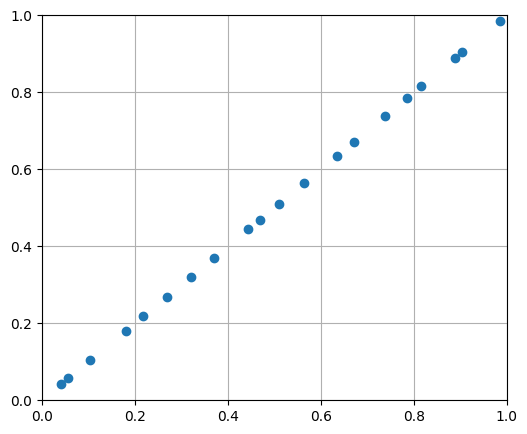

In [152]:
x = lhs_1(n=20)

plt.figure(figsize=(6, 5))
plt.scatter(x, x)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.grid()
plt.show()

Multidimensional - 2D

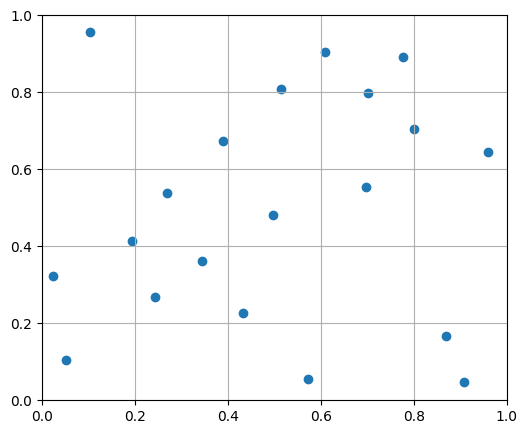

In [153]:
x = lhs_d(n=20, d=2)

plt.figure(figsize=(6, 5))
plt.scatter(x[:, 0], x[:, 1])
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.grid()
plt.show()